# Notebook 3: Evaluación y Análisis de Resultados (TFM)

Este cuaderno realiza el **posprocesamiento exclusivo** de las trayectorias e instantes temporales guardados en disco.

### Características del Cuaderno:
1. **Sin re-ejecutar simulaciones:** Carga en frío los archivos de resultados (`.json` y `.csv`) generados por los cuadernos de pruebas.
2. **Evaluador Unificado (`PathEvaluatorTFM`):** Calcula de forma automatizada la Tasa de Acierto, Pasos a la Meta, Probabilidad Acumulada, Área Cubierta ($m^2$) y Distancia Recorrida ($m$).
3. **Evolución Temporal del Mapa de Creencias $b(v^k)$:** Genera las gráficas del mapa de creencias actualizado en instantes de tiempo adaptativos ($t=0, 250, 500, 1000$), mostrando la zona de barrido de la cámara en azul y la trayectoria del dron.
4. **Idioma de las Gráficas:** Todas las figuras, leyendas y ejes están etiquetados en **inglés** para su inclusión directa en la memoria y artículos académicos.

In [1]:
import os
import sys

# Si el cuaderno se ejecuta desde su propia carpeta (TFM_JC/pruebas), cambiamos a la raíz del framework MTS
if os.path.basename(os.getcwd()) == "pruebas":
    os.chdir("../..")
elif os.path.basename(os.getcwd()) == "TFM_JC":
    os.chdir("..")
print(f"Directorio de trabajo actual: {os.getcwd()}")


Directorio de trabajo actual: c:\Users\juanc\Desktop\TFM\TFM-Juan Carlos\Software\framwork-MTS\MTS-UncertainEnvironment-Algoritmos-bioinspirados


## 1. Importación de Librerías y Carga de Datos

Importamos pandas, matplotlib y seaborn, y cargamos el archivo CSV consolidado con los resultados de evaluación de las simulaciones.

In [2]:
%matplotlib inline
import os
import sys
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from TFM_JC.scripts.path_evaluator_tfm import PathEvaluatorTFM
import TFM_JC.scripts.visualizacion_pro as vis_pro

print("=== Módulo Evaluador Unificado (PathEvaluatorTFM) Cargado ===")

# Carga de datos de evaluación consolidados
csv_path = "TFM_JC/resultados/resultados_evaluacion_tfm.csv"
if os.path.exists(csv_path):
    df_eval = pd.read_csv(csv_path)
    print(f"Resultados cargados con éxito desde {csv_path}: {len(df_eval)} evaluaciones.")
else:
    print(f"Advertencia: No se encontró el archivo CSV en {csv_path}")


=== Módulo Evaluador Unificado (PathEvaluatorTFM) Cargado ===
Resultados cargados con éxito desde TFM_JC/resultados/resultados_evaluacion_tfm.csv: 900 evaluaciones.


## 2. Resumen de Estadísticos Descriptivos

Agrupamos los resultados por perfil de víctima y algoritmo de búsqueda para consultar la tasa media de acierto, la distancia recorrida y los pasos ejecutados.

In [3]:
if 'df_eval' in locals():
    summary = df_eval.groupby(["Perfil", "Algoritmo"]).agg({
        "Acierto_Informada": ["mean", "std"],
        "Acierto_Ciega": ["mean", "std"],
        "Distancia_km": "mean",
        "Area_Covered_km2": "mean",
        "Likelihood_Score": "mean",
        "Pasos": "mean"
    }).round(3)
    display(summary)
else:
    print("df_eval not loaded.")

Acierto_Informada        Acierto_Ciega         \
                                     mean    std          mean    std   
Perfil     Algoritmo                                                    
autista    ABC                      4.942  1.486         1.740  0.511   
           ACO                      3.696  1.341         1.594  0.329   
           BHA                      5.058  1.506         1.832  0.577   
           expanding_sq             6.014  0.608         2.360  0.283   
           lawnmower                1.500  0.000         1.400  0.000   
           voraz-heur               4.888  0.085         2.090  0.071   
demencia   ABC                      7.622  1.283         1.140  0.328   
           ACO                      7.036  1.744         1.278  0.409   
           BHA                      7.614  1.944         1.122  0.361   
           expanding_sq             8.932  0.892         1.670  0.164   
           lawnmower                2.300  0.000         2.300  0.000   
           voraz-heur               5.414  0.476         0.782  0.090   
senderista ABC                      4.978  1.137         1.962  0.347   
           ACO                      3.110  1.090         1.520  0.404   
           BHA                      5.194  1.227         2.060  0.436   
           expanding_sq             5.464  0.807         2.544  0.331   
           lawnmower                1.390  0.071         2.176  0.156   
           voraz-heur              13.014  2.310         5.936  1.222   

                        Distancia_km Area_Covered_km2 Likelihood_Score  \
                                mean             mean             mean   
Perfil     Algoritmo                                                     
autista    ABC                11.218            0.201            0.056   
           ACO                11.924            0.178            0.042   
           BHA                11.197            0.206            0.057   
           expanding_sq        9.850            0.282            0.066   
           lawnmower          10.829            0.848            0.015   
           voraz-heur         12.337            0.238            0.063   
demencia   ABC                11.552            0.172            0.075   
           ACO                11.661            0.179            0.071   
           BHA                11.053            0.172            0.074   
           expanding_sq        9.812            0.281            0.092   
           lawnmower          10.829            0.848            0.019   
           voraz-heur         12.423            0.100            0.048   
senderista ABC                11.605            0.210            0.048   
           ACO                11.756            0.170            0.031   
           BHA                11.488            0.218            0.050   
           expanding_sq        9.771            0.280            0.056   
           lawnmower          10.467            0.822            0.014   
           voraz-heur         10.640            0.730            0.115   

                           Pasos  
                            mean  
Perfil     Algoritmo              
autista    ABC            927.86  
           ACO            986.54  
           BHA            927.54  
           expanding_sq   982.12  
           lawnmower     1001.00  
           voraz-heur     983.80  
demencia   ABC            953.08  
           ACO            961.96  
           BHA            916.18  
           expanding_sq   978.26  
           lawnmower     1001.00  
           voraz-heur     982.62  
senderista ABC            960.36  
           ACO            974.66  
           BHA            952.02  
           expanding_sq   974.18  
           lawnmower      965.96  
           voraz-heur     932.66

## 3. Diagramas de Caja y Bigotes (Boxplots)

Generamos los diagramas comparativos mostrando las distribuciones de la tasa de acierto, score de verosimilitud, área cubierta y distancia recorrida para cada algoritmo a lo largo de los tres perfiles de víctima.

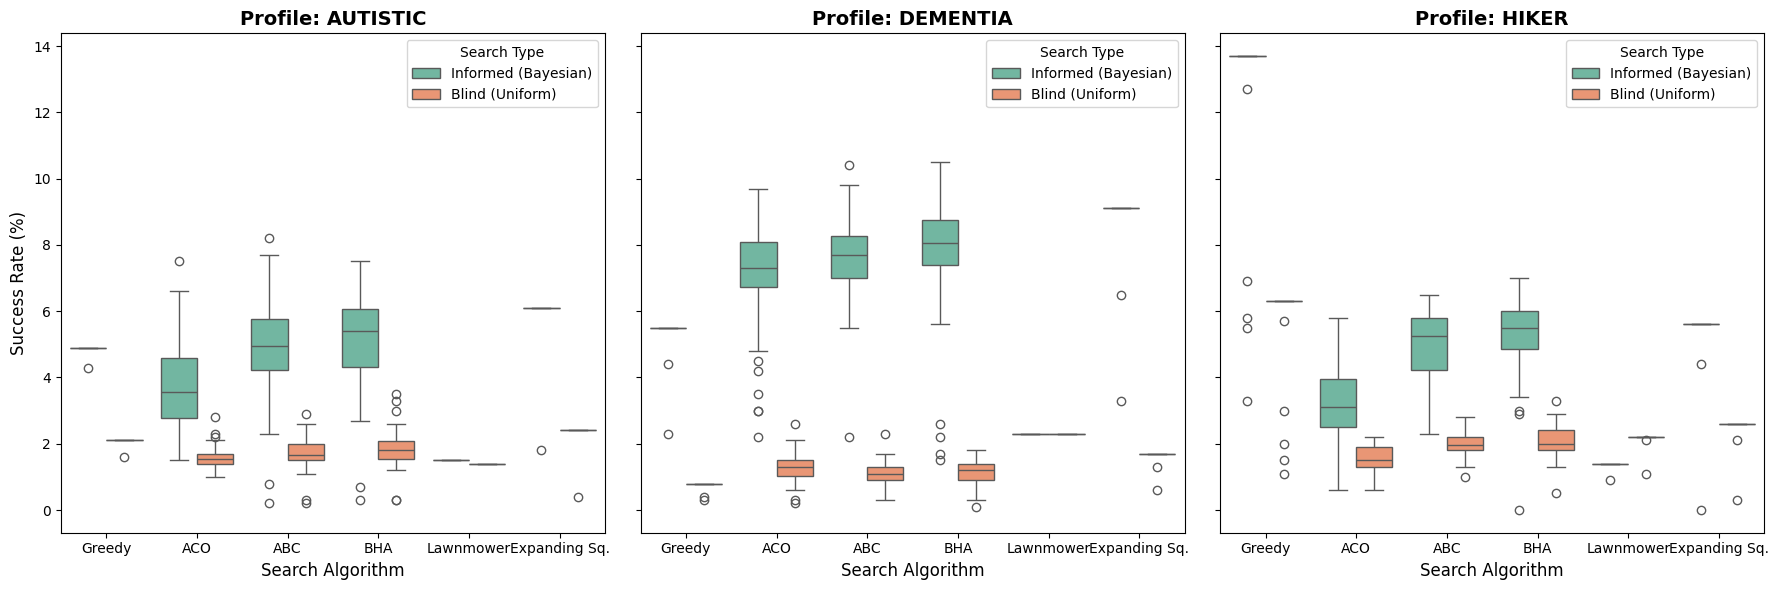

Success rate plot saved to: TFM_JC/resultados/graficas/comparativa_acierto_perfiles.png


C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


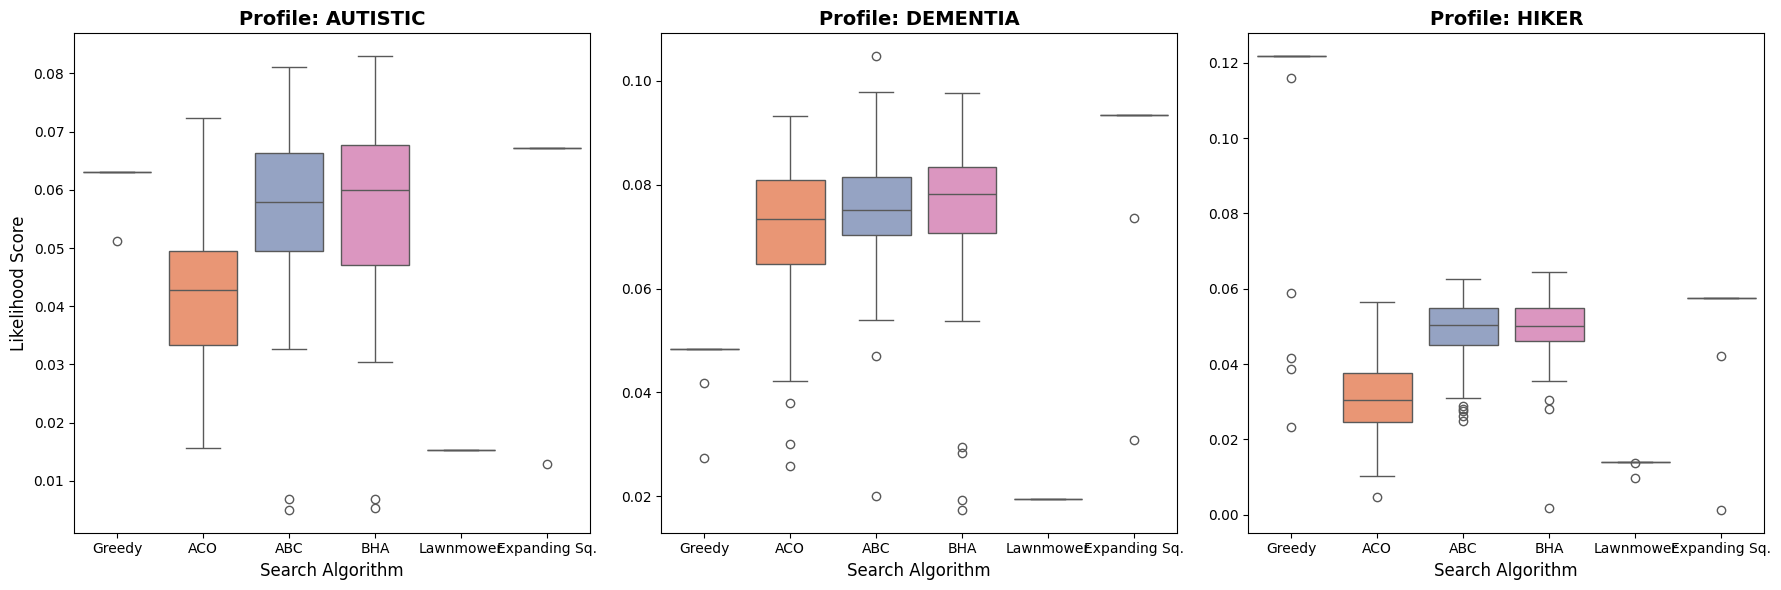

Likelihood score plot saved to: TFM_JC/resultados/graficas/comparativa_likelihood_perfiles.png


C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


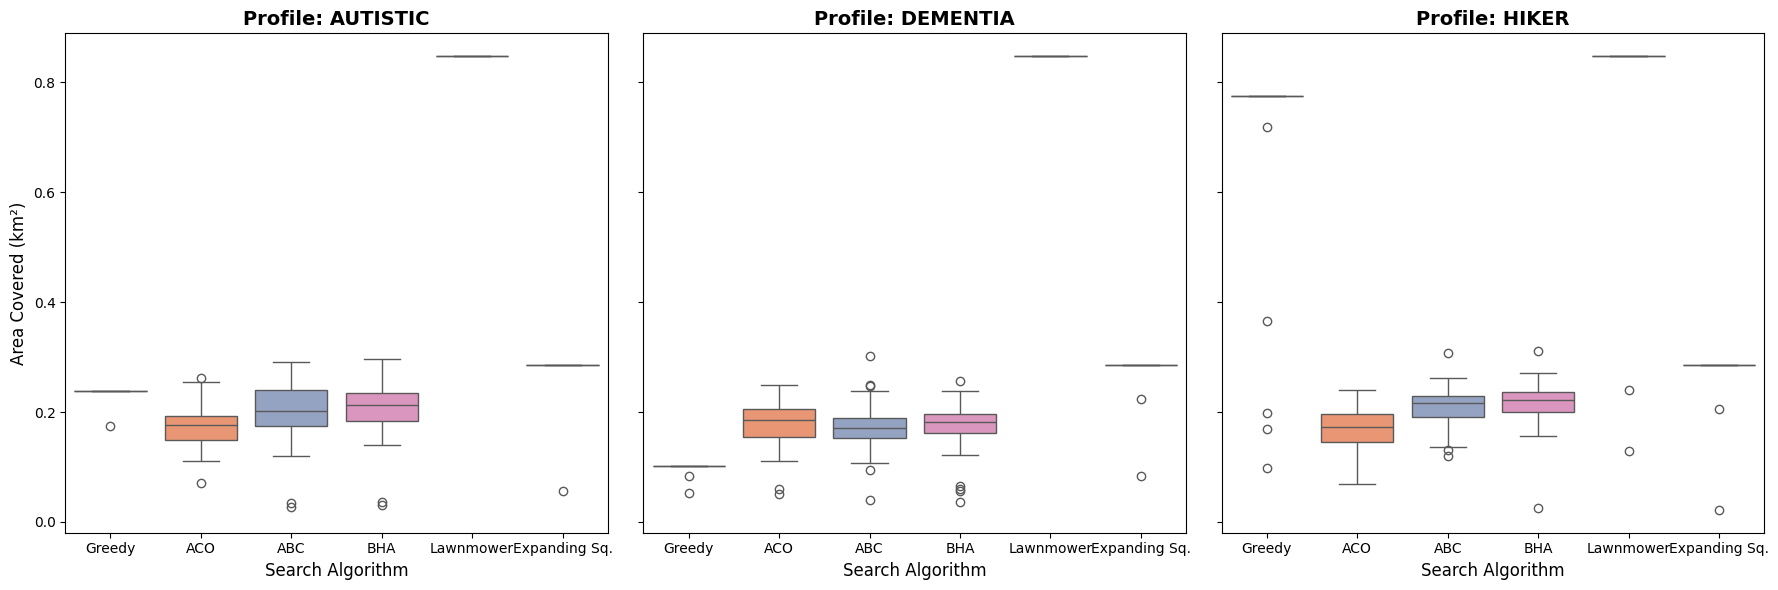

Area covered plot saved to: TFM_JC/resultados/graficas/comparativa_area_perfiles.png


C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


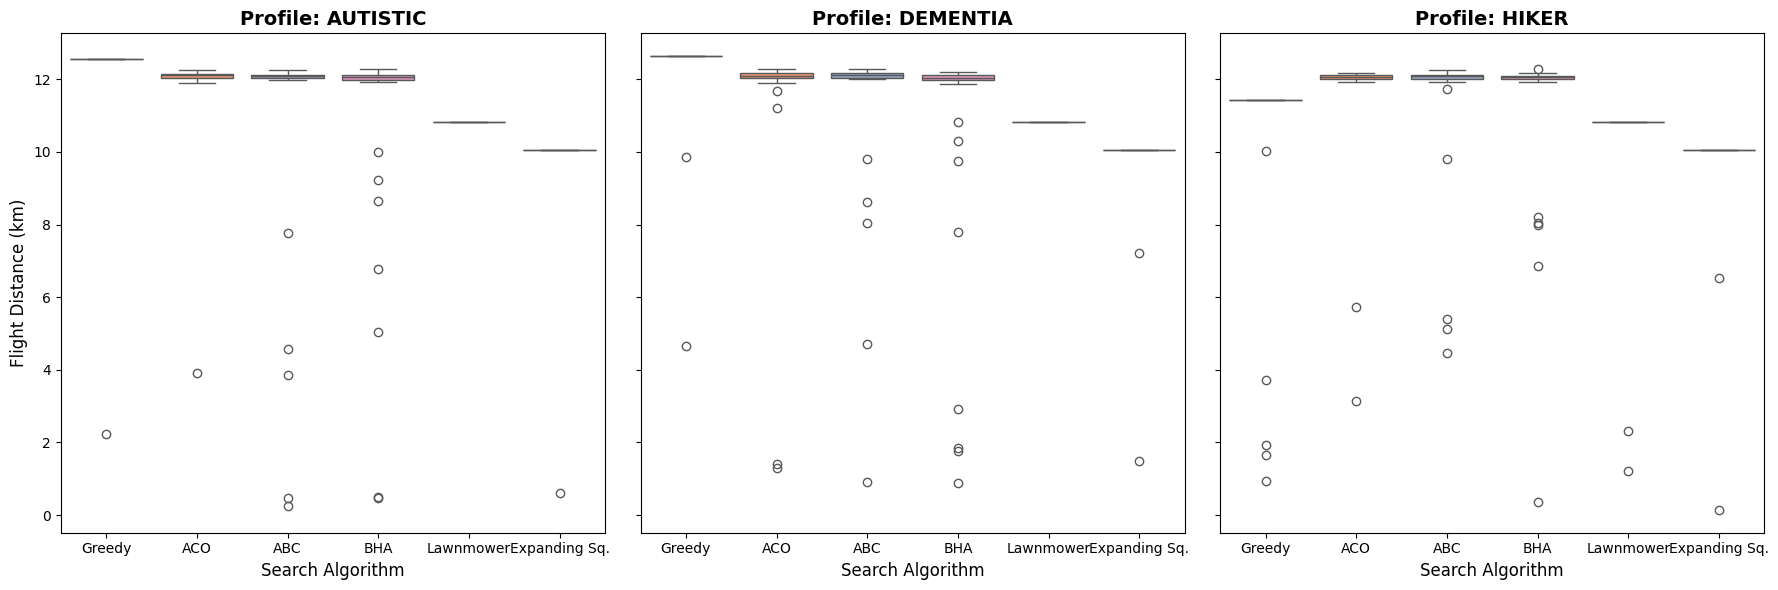

Flight distance plot saved to: TFM_JC/resultados/graficas/comparativa_distancia_perfiles.png


C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\juanc\AppData\Local\Temp\ipykernel_19356\4290373625.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


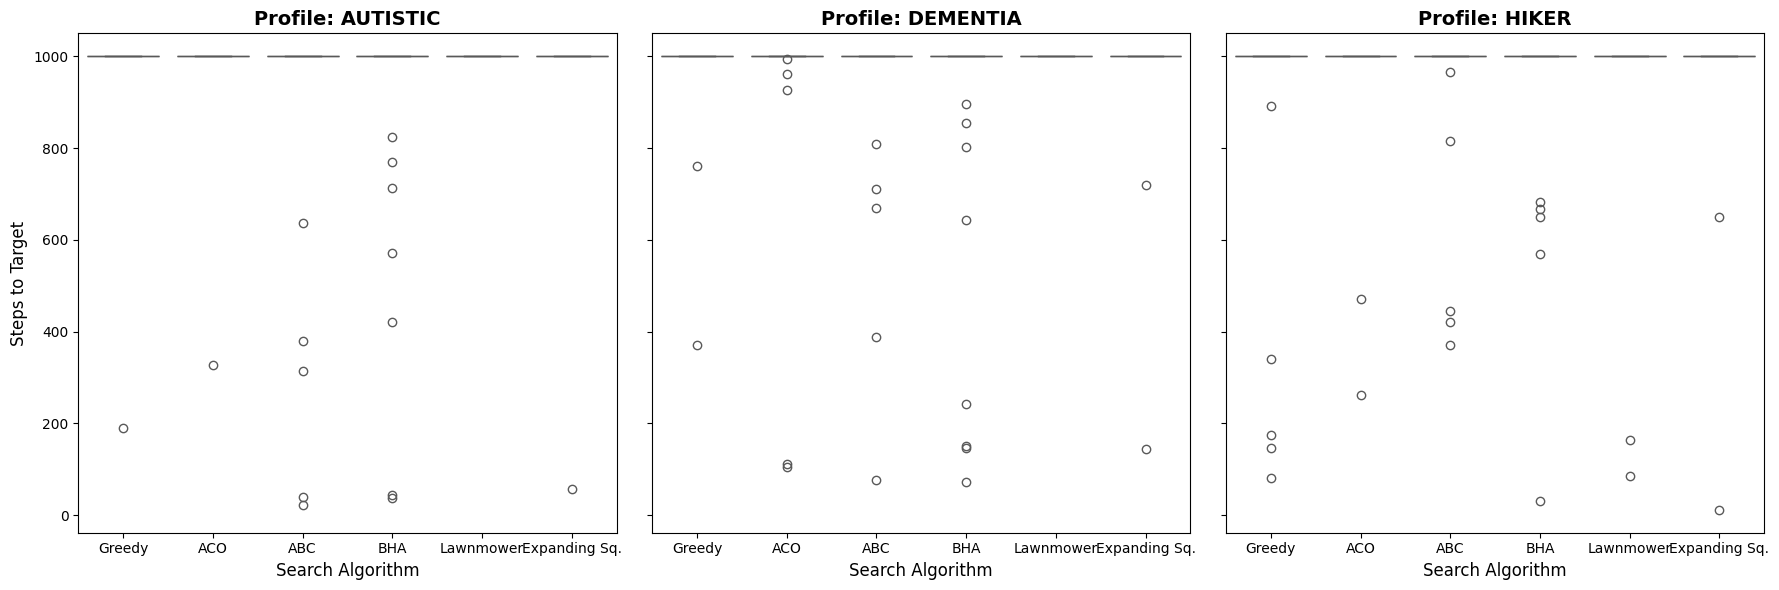

Steps to target plot saved to: TFM_JC/resultados/graficas/comparativa_pasos_encontrar.png


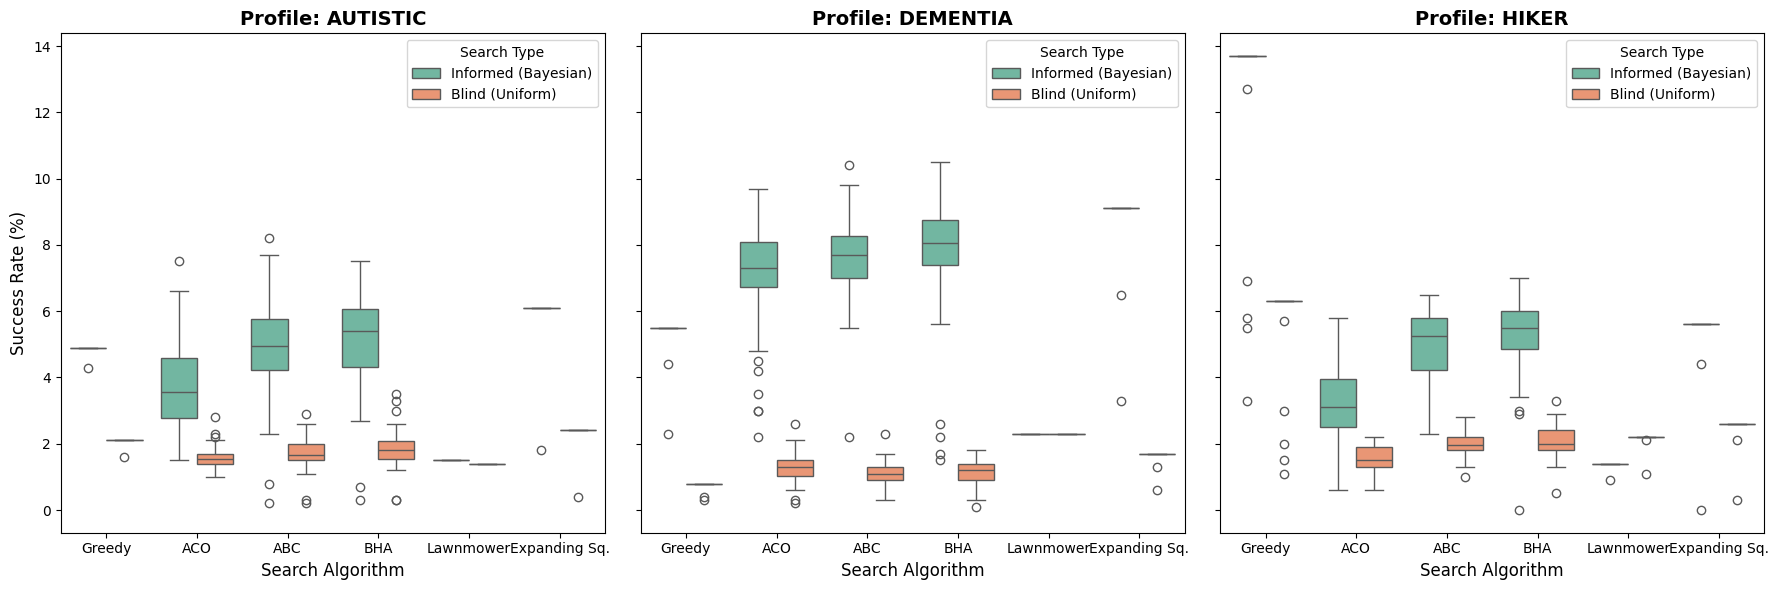

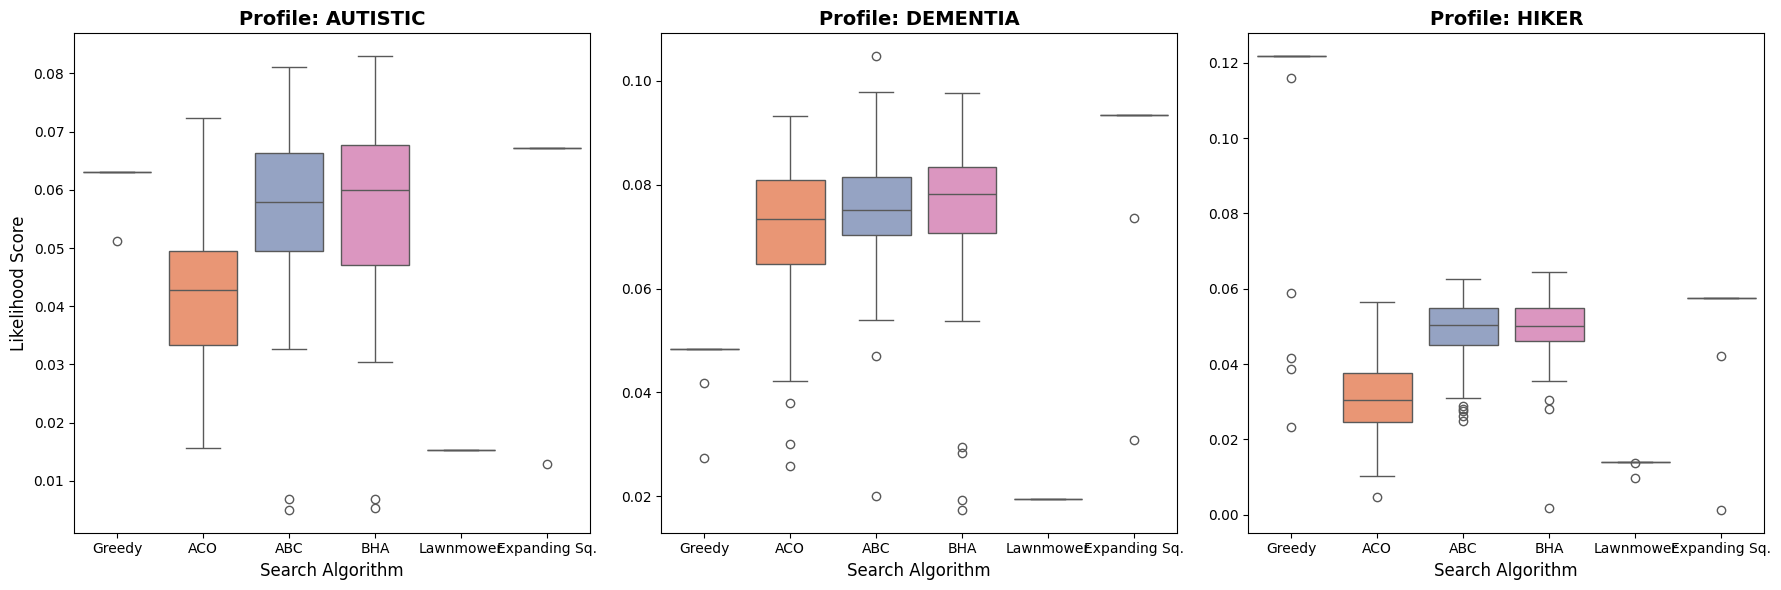

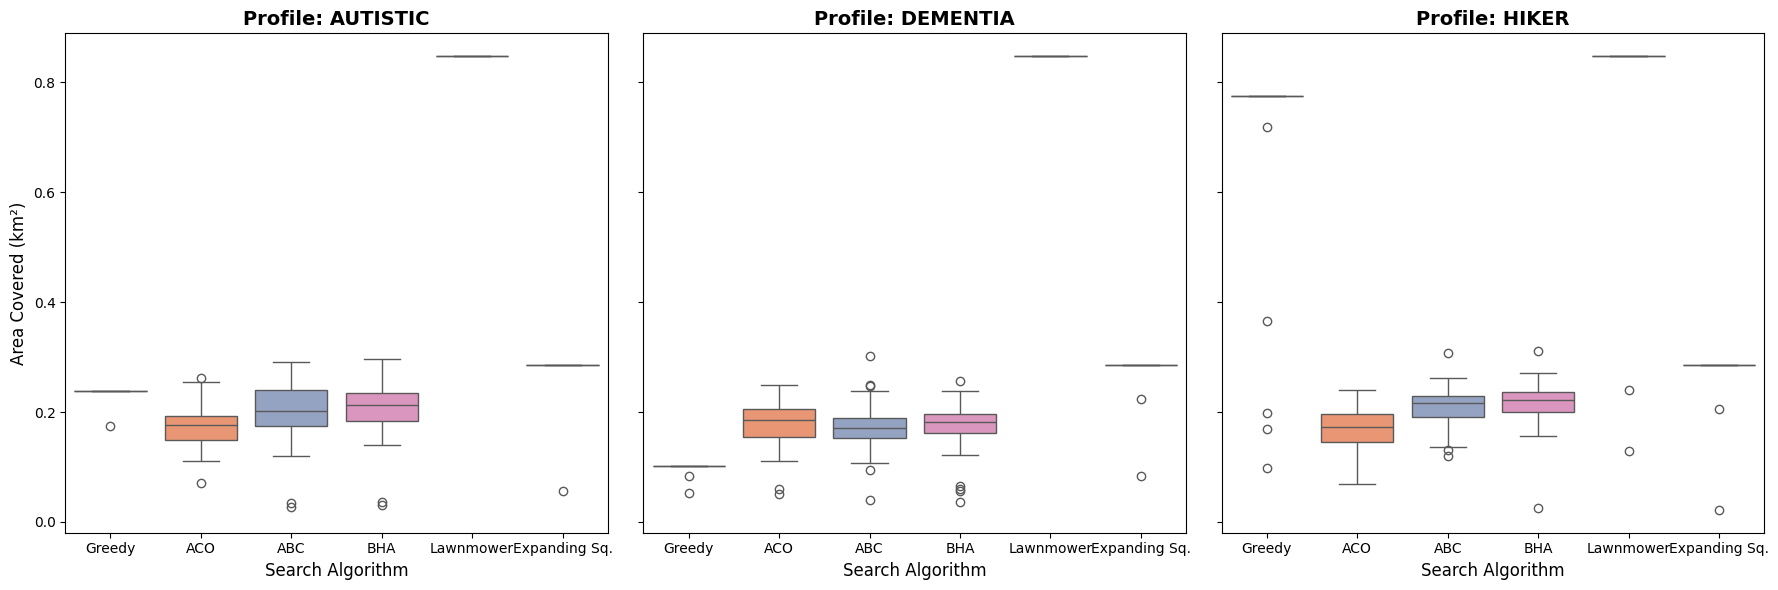

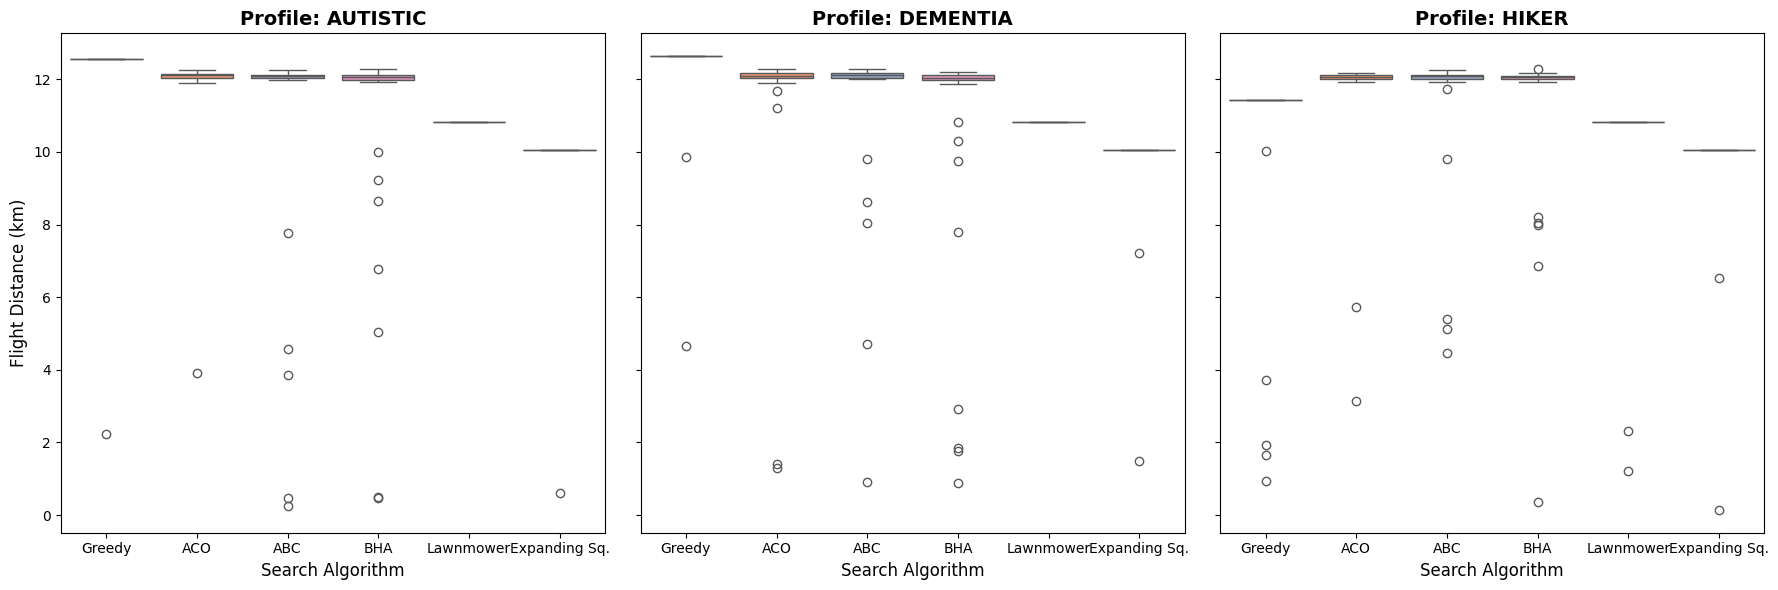

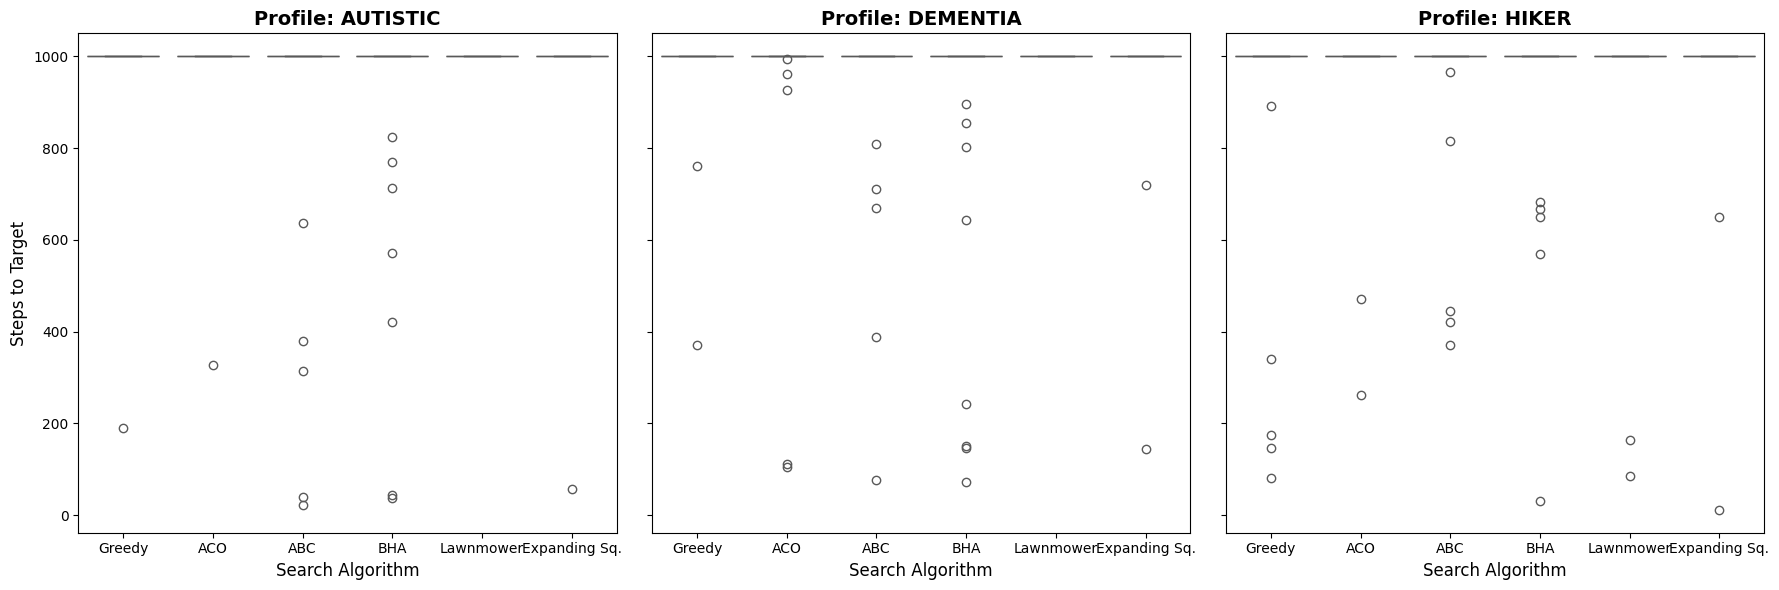

In [4]:
if 'df_eval' in locals():
    perfiles = ["autista", "demencia", "senderista"]
    alg_map_display = {
        "voraz-heur": "Greedy",
        "ACO": "ACO",
        "ABC": "ABC",
        "BHA": "BHA",
        "lawnmower": "Lawnmower",
        "expanding_sq": "Expanding Sq."
    }

    # Create directory for graphics if not exists
    os.makedirs("TFM_JC/resultados/graficas", exist_ok=True)

    # 1. Success Rate (Informed vs Blind)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for i, perfil in enumerate(perfiles):
        sub_df = df_eval[df_eval["Perfil"] == perfil]
        if sub_df.empty: 
            continue
        df_melt = sub_df.melt(
            id_vars=["Algoritmo"], 
            value_vars=["Acierto_Informada", "Acierto_Ciega"], 
            var_name="Search Type", 
            value_name="Success Rate (%)"
        )
        df_melt["Search Type"] = df_melt["Search Type"].map({
            "Acierto_Informada": "Informed (Bayesian)",
            "Acierto_Ciega": "Blind (Uniform)"
        })
        df_melt["Algoritmo"] = df_melt["Algoritmo"].map(alg_map_display)
        
        sns.boxplot(
            data=df_melt, 
            x="Algoritmo", 
            y="Success Rate (%)", 
            hue="Search Type", 
            ax=axes[i],
            palette="Set2",
            order=["Greedy", "ACO", "ABC", "BHA", "Lawnmower", "Expanding Sq."]
        )
        perfil_en = "AUTISTIC" if perfil == "autista" else ("DEMENTIA" if perfil == "demencia" else "HIKER")
        axes[i].set_title(f"Profile: {perfil_en}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Search Algorithm", fontsize=12)
        if i == 0:
            axes[i].set_ylabel("Success Rate (%)", fontsize=12)
        else:
            axes[i].set_ylabel("")
    plt.tight_layout()
    graph_path_acierto = "TFM_JC/resultados/graficas/comparativa_acierto_perfiles.png"
    plt.savefig(graph_path_acierto, dpi=300)
    display(fig)
    # plt.close(fig)
    print(f"Success rate plot saved to: {graph_path_acierto}")

    # 2. Likelihood Score
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    for i, perfil in enumerate(perfiles):
        sub_df = df_eval[df_eval["Perfil"] == perfil]
        if sub_df.empty: 
            continue
        sub_df_copy = sub_df.copy()
        sub_df_copy["Algoritmo"] = sub_df_copy["Algoritmo"].map(alg_map_display)
        sns.boxplot(
            data=sub_df_copy, 
            x="Algoritmo", 
            y="Likelihood_Score", 
            ax=axes[i], 
            palette="Set2",
            order=["Greedy", "ACO", "ABC", "BHA", "Lawnmower", "Expanding Sq."]
        )
        perfil_en = "AUTISTIC" if perfil == "autista" else ("DEMENTIA" if perfil == "demencia" else "HIKER")
        axes[i].set_title(f"Profile: {perfil_en}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Search Algorithm", fontsize=12)
        if i == 0:
            axes[i].set_ylabel("Likelihood Score", fontsize=12)
        else:
            axes[i].set_ylabel("")
    plt.tight_layout()
    graph_path_like = "TFM_JC/resultados/graficas/comparativa_likelihood_perfiles.png"
    plt.savefig(graph_path_like, dpi=300)
    display(fig)
    # plt.close(fig)
    print(f"Likelihood score plot saved to: {graph_path_like}")

    # 3. Area Covered
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for i, perfil in enumerate(perfiles):
        sub_df = df_eval[df_eval["Perfil"] == perfil]
        if sub_df.empty: 
            continue
        sub_df_copy = sub_df.copy()
        sub_df_copy["Algoritmo"] = sub_df_copy["Algoritmo"].map(alg_map_display)
        sns.boxplot(
            data=sub_df_copy, 
            x="Algoritmo", 
            y="Area_Covered_km2", 
            ax=axes[i], 
            palette="Set2",
            order=["Greedy", "ACO", "ABC", "BHA", "Lawnmower", "Expanding Sq."]
        )
        perfil_en = "AUTISTIC" if perfil == "autista" else ("DEMENTIA" if perfil == "demencia" else "HIKER")
        axes[i].set_title(f"Profile: {perfil_en}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Search Algorithm", fontsize=12)
        if i == 0:
            axes[i].set_ylabel("Area Covered (km²)", fontsize=12)
        else:
            axes[i].set_ylabel("")
    plt.tight_layout()
    graph_path_area = "TFM_JC/resultados/graficas/comparativa_area_perfiles.png"
    plt.savefig(graph_path_area, dpi=300)
    display(fig)
    # plt.close(fig)
    print(f"Area covered plot saved to: {graph_path_area}")

    # 4. Flight Distance
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for i, perfil in enumerate(perfiles):
        sub_df = df_eval[df_eval["Perfil"] == perfil]
        if sub_df.empty: 
            continue
        sub_df_copy = sub_df.copy()
        sub_df_copy["Algoritmo"] = sub_df_copy["Algoritmo"].map(alg_map_display)
        sns.boxplot(
            data=sub_df_copy, 
            x="Algoritmo", 
            y="Distancia_km", 
            ax=axes[i], 
            palette="Set2",
            order=["Greedy", "ACO", "ABC", "BHA", "Lawnmower", "Expanding Sq."]
        )
        perfil_en = "AUTISTIC" if perfil == "autista" else ("DEMENTIA" if perfil == "demencia" else "HIKER")
        axes[i].set_title(f"Profile: {perfil_en}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Search Algorithm", fontsize=12)
        if i == 0:
            axes[i].set_ylabel("Flight Distance (km)", fontsize=12)
        else:
            axes[i].set_ylabel("")
    plt.tight_layout()
    graph_path_dist = "TFM_JC/resultados/graficas/comparativa_distancia_perfiles.png"
    plt.savefig(graph_path_dist, dpi=300)
    display(fig)
    # plt.close(fig)
    print(f"Flight distance plot saved to: {graph_path_dist}")

    # 5. Steps to Target
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    for i, perfil in enumerate(perfiles):
        sub_df = df_eval[df_eval["Perfil"] == perfil]
        if sub_df.empty: 
            continue
        sub_df_copy = sub_df.copy()
        sub_df_copy["Algoritmo"] = sub_df_copy["Algoritmo"].map(alg_map_display)
        sns.boxplot(
            data=sub_df_copy, 
            x="Algoritmo", 
            y="Pasos", 
            ax=axes[i], 
            palette="Set2",
            order=["Greedy", "ACO", "ABC", "BHA", "Lawnmower", "Expanding Sq."]
        )
        perfil_en = "AUTISTIC" if perfil == "autista" else ("DEMENTIA" if perfil == "demencia" else "HIKER")
        axes[i].set_title(f"Profile: {perfil_en}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Search Algorithm", fontsize=12)
        if i == 0:
            axes[i].set_ylabel("Steps to Target", fontsize=12)
        else:
            axes[i].set_ylabel("")
    plt.tight_layout()
    graph_path_steps = "TFM_JC/resultados/graficas/comparativa_pasos_encontrar.png"
    plt.savefig(graph_path_steps, dpi=300)
    display(fig)
    # plt.close(fig)
    print(f"Steps to target plot saved to: {graph_path_steps}")
else:
    print("df_eval not loaded.")


## 4. Visualización de la Evolución Temporal de la Búsqueda

Para ilustrar el comportamiento en tiempo real de los algoritmos, representamos las trayectorias de búsqueda sobre el mapa geográfico. A continuación se generan las tres figuras principales:
1. **Escenario Inicial de Búsqueda:** Muestra el LKP de inicio del dron (círculo azul) y la ubicación de la víctima (X roja) sobre el mapa de calor probabilístico.
2. **Evolución Temporal $b(v^k)$:** Muestra la evolución del mapa de creencias y la ruta del dron en instantes de tiempo adaptativos ($t=0, 250, 500, 1000$).
3. **Comparativa Lado a Lado:** Compara directamente dos algoritmos (ej. Colonia de Abejas ABC vs Agujero Negro BHA) en los mismos instantes de búsqueda.

=== Mostrando Gráficas de Trayectorias y Creencias para Perfil: AUTISTA ===
Mapa del escenario inicial guardado en: TFM_JC/resultados/graficas/escenario_inicial_autista.png


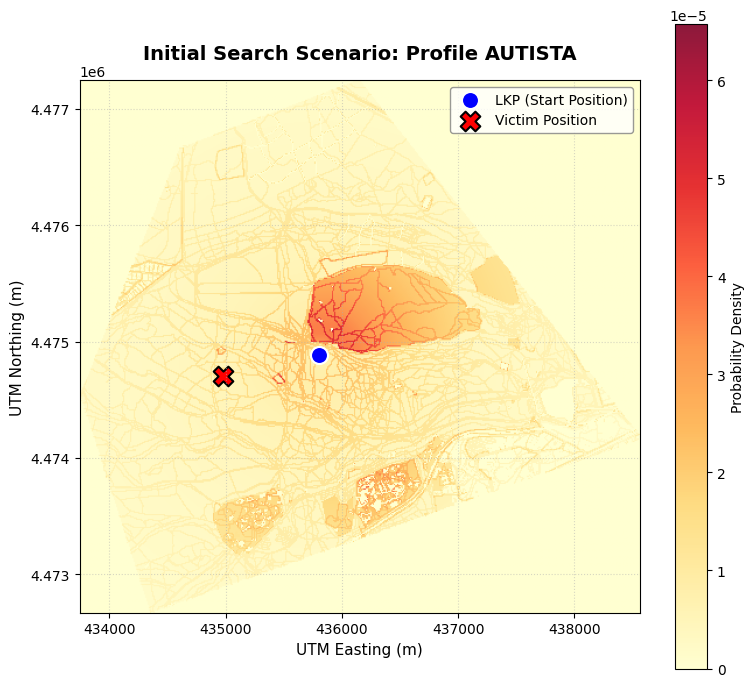

Gráfica de filtro de restricciones guardada en: TFM_JC/resultados/graficas/filtro_restricciones_autista.png


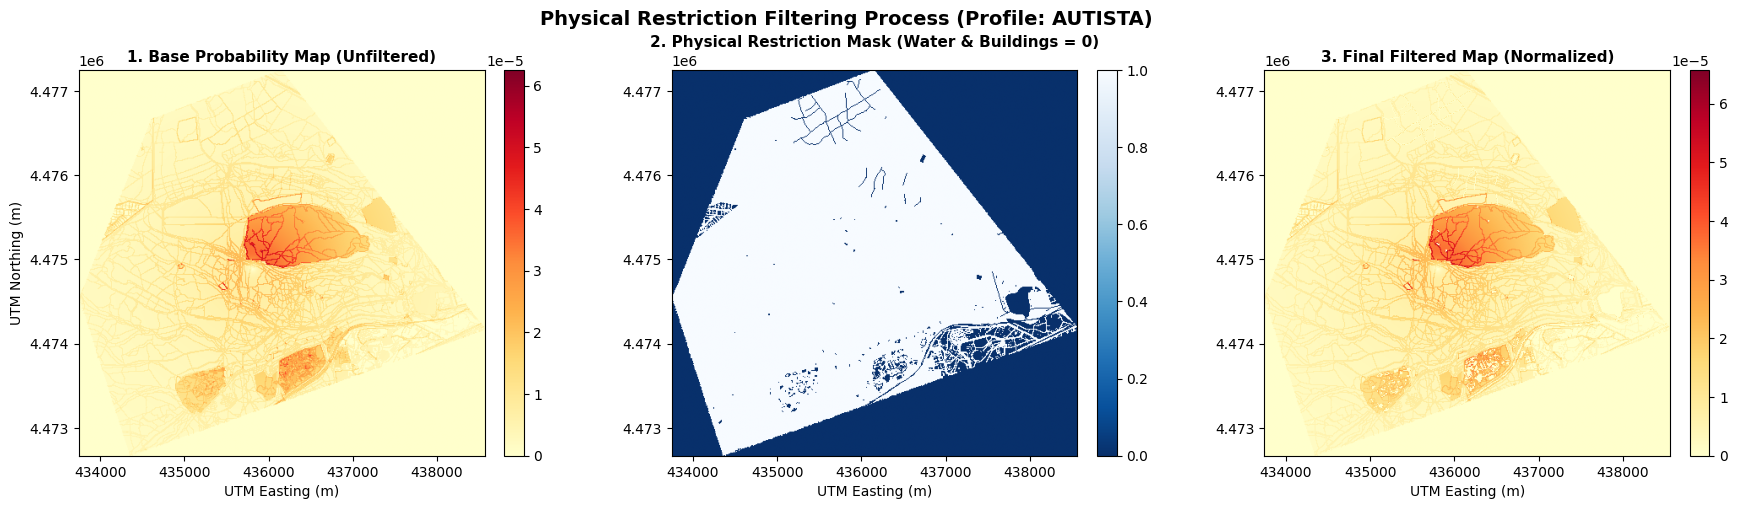

Evolución temporal b(v^k) guardada en: TFM_JC/resultados/graficas/evolucion_temporal_autista_abc.png


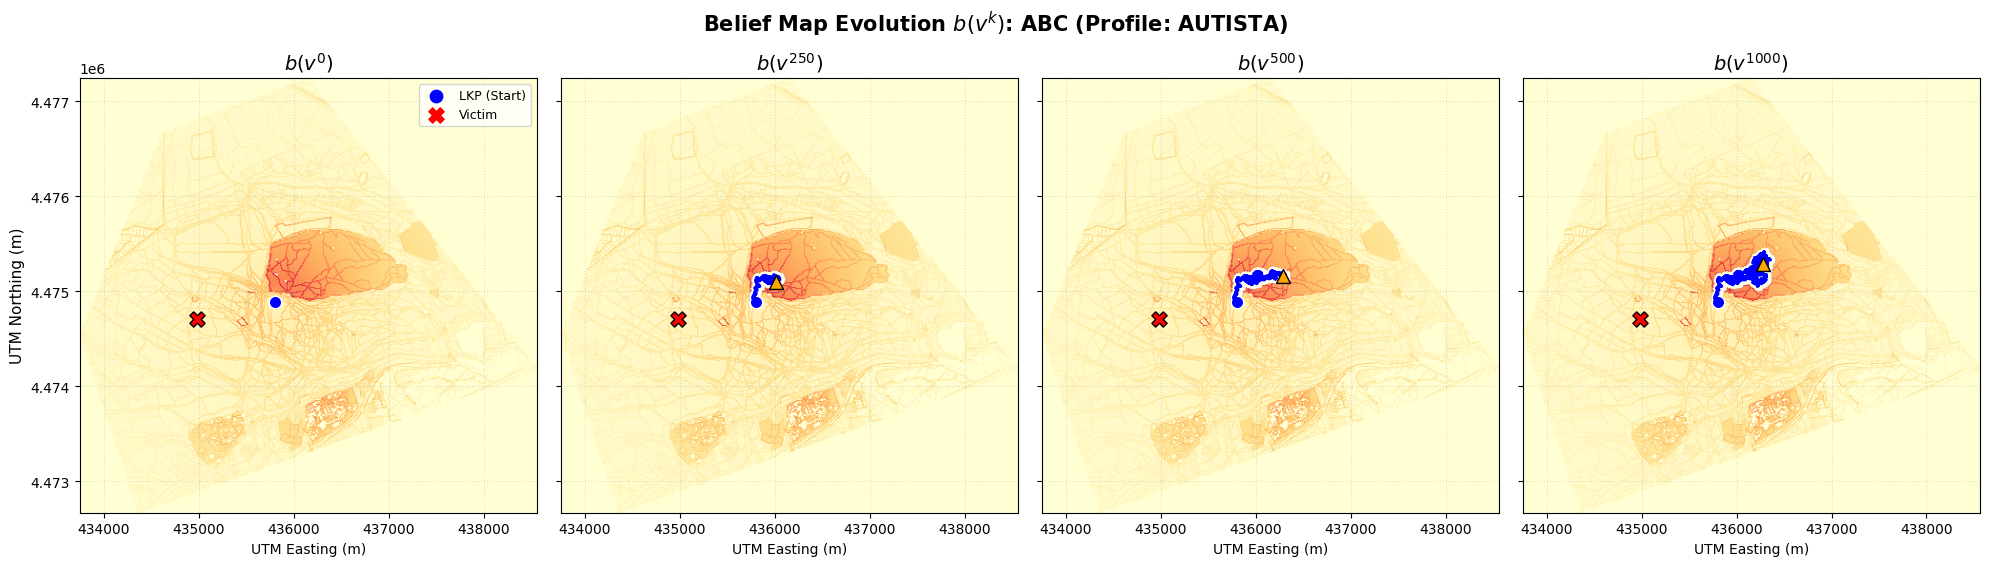

Comparativa lado a lado guardada en: TFM_JC/resultados/graficas/comparativa_evolucion_autista_abc_vs_bha.png


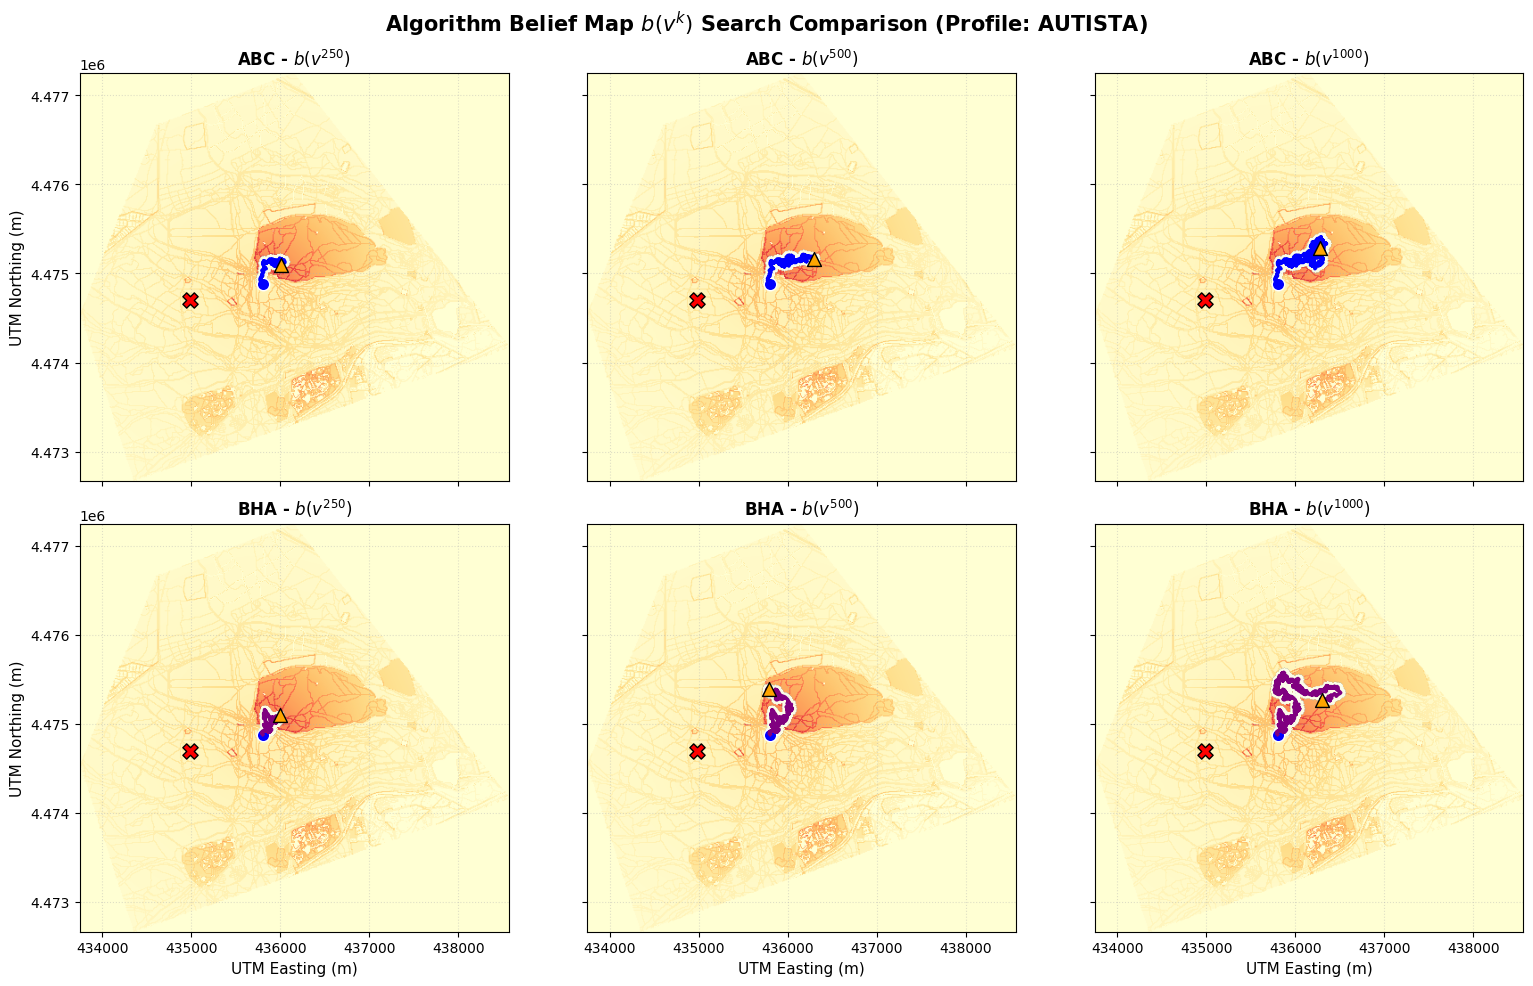

=== Mostrando Gráficas de Trayectorias y Creencias para Perfil: DEMENCIA ===
Mapa del escenario inicial guardado en: TFM_JC/resultados/graficas/escenario_inicial_demencia.png


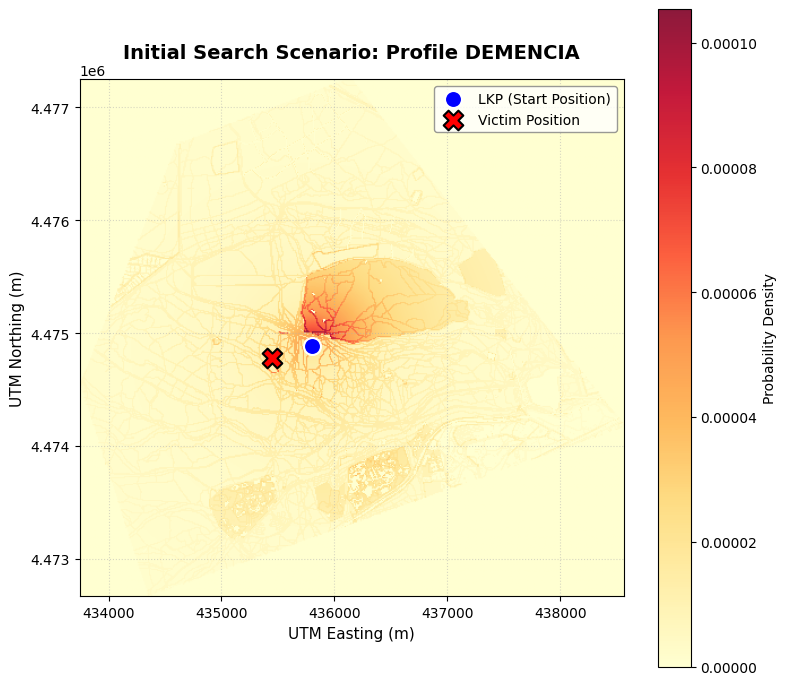

Gráfica de filtro de restricciones guardada en: TFM_JC/resultados/graficas/filtro_restricciones_demencia.png


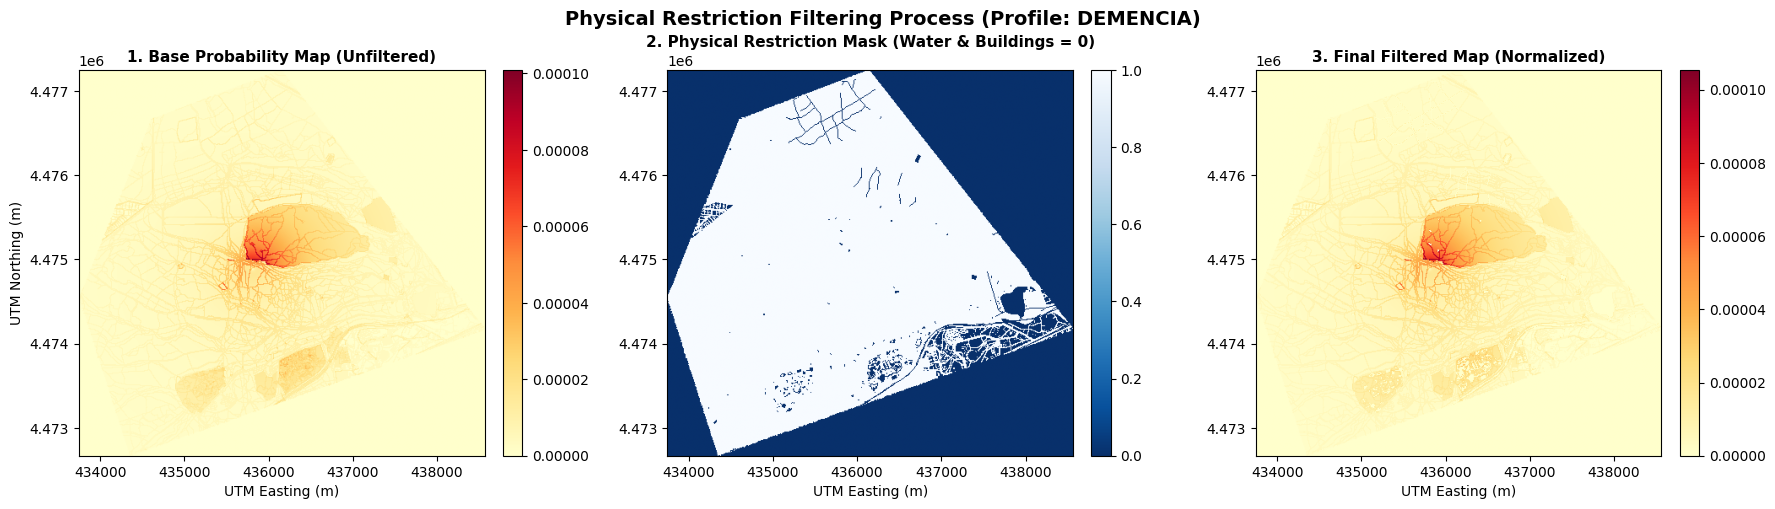

Evolución temporal b(v^k) guardada en: TFM_JC/resultados/graficas/evolucion_temporal_demencia_abc.png


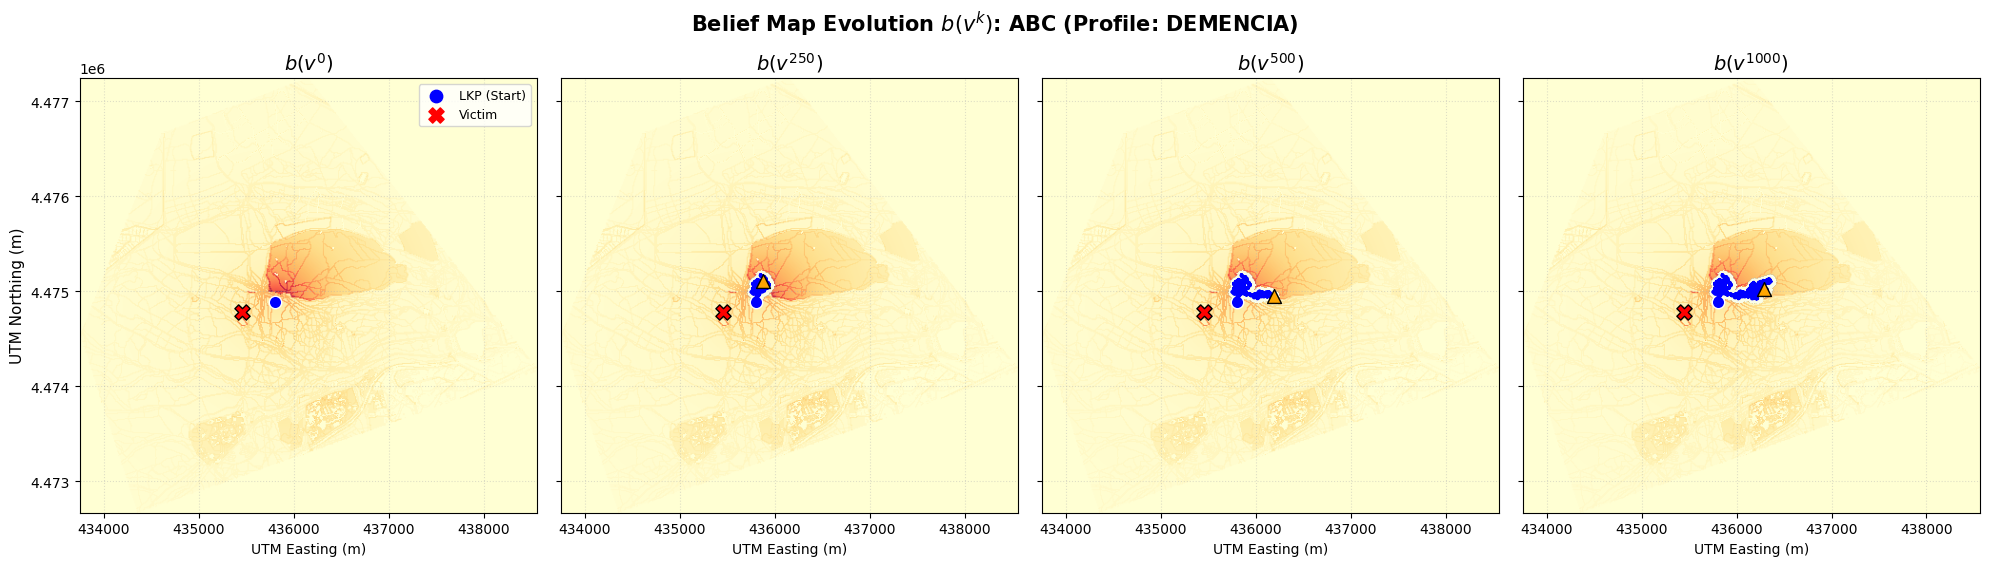

Comparativa lado a lado guardada en: TFM_JC/resultados/graficas/comparativa_evolucion_demencia_abc_vs_bha.png


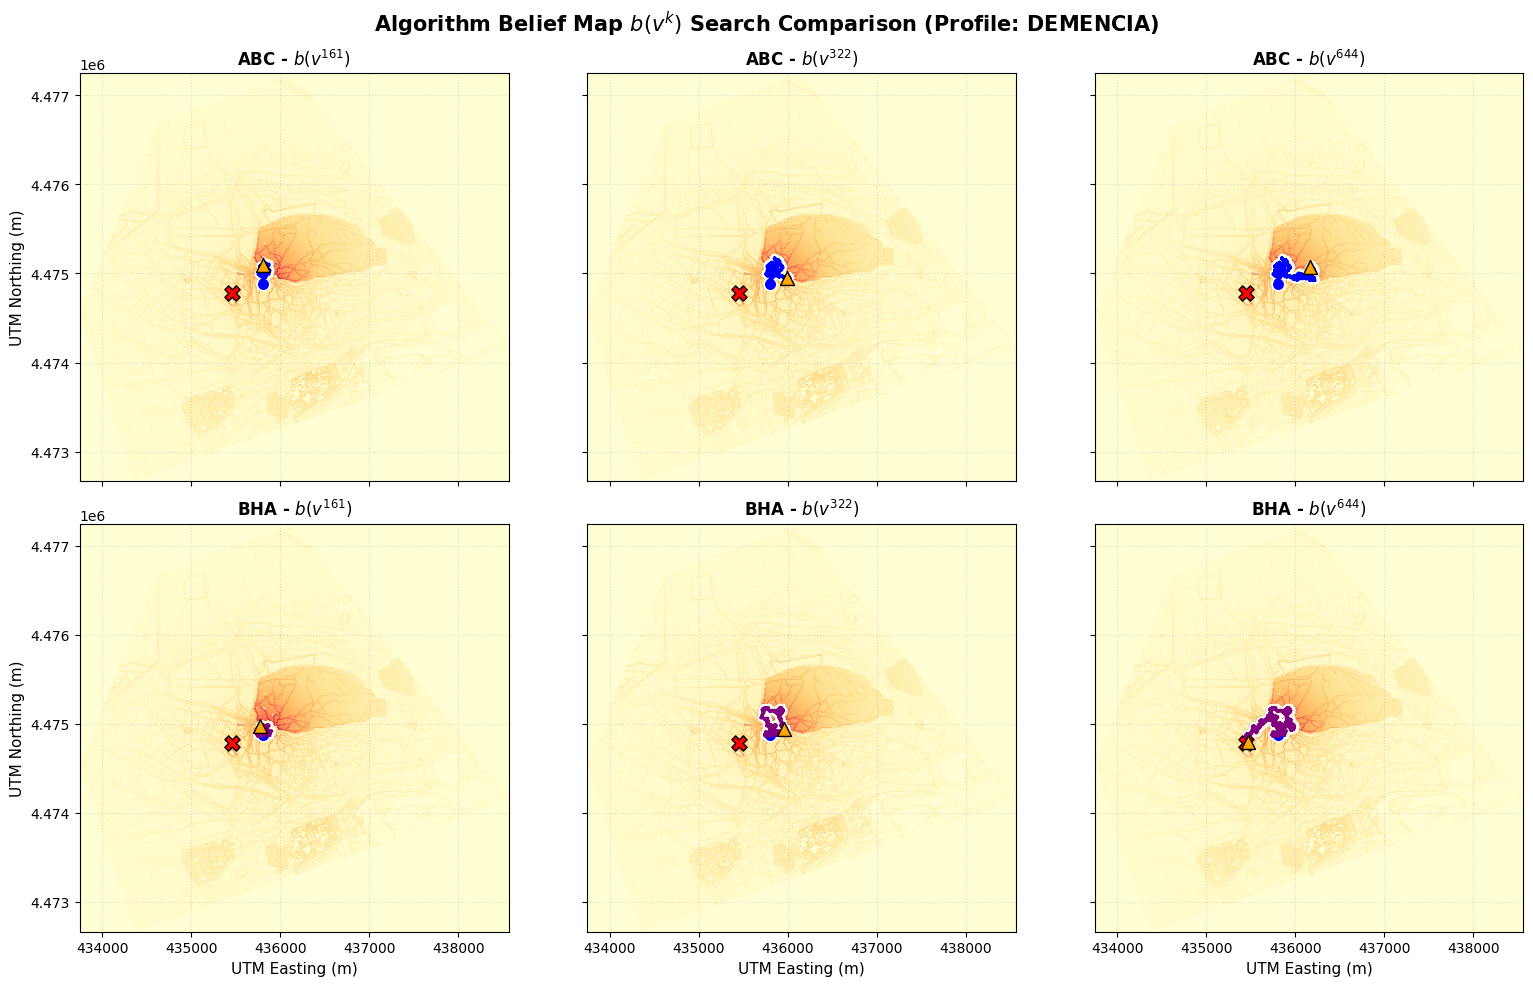

=== Mostrando Gráficas de Trayectorias y Creencias para Perfil: SENDERISTA ===
Mapa del escenario inicial guardado en: TFM_JC/resultados/graficas/escenario_inicial_senderista.png


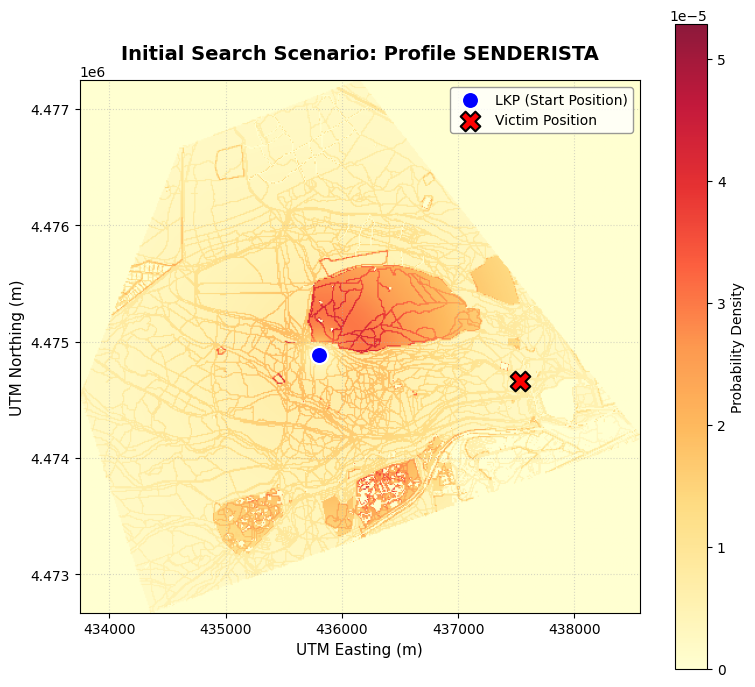

Gráfica de filtro de restricciones guardada en: TFM_JC/resultados/graficas/filtro_restricciones_senderista.png


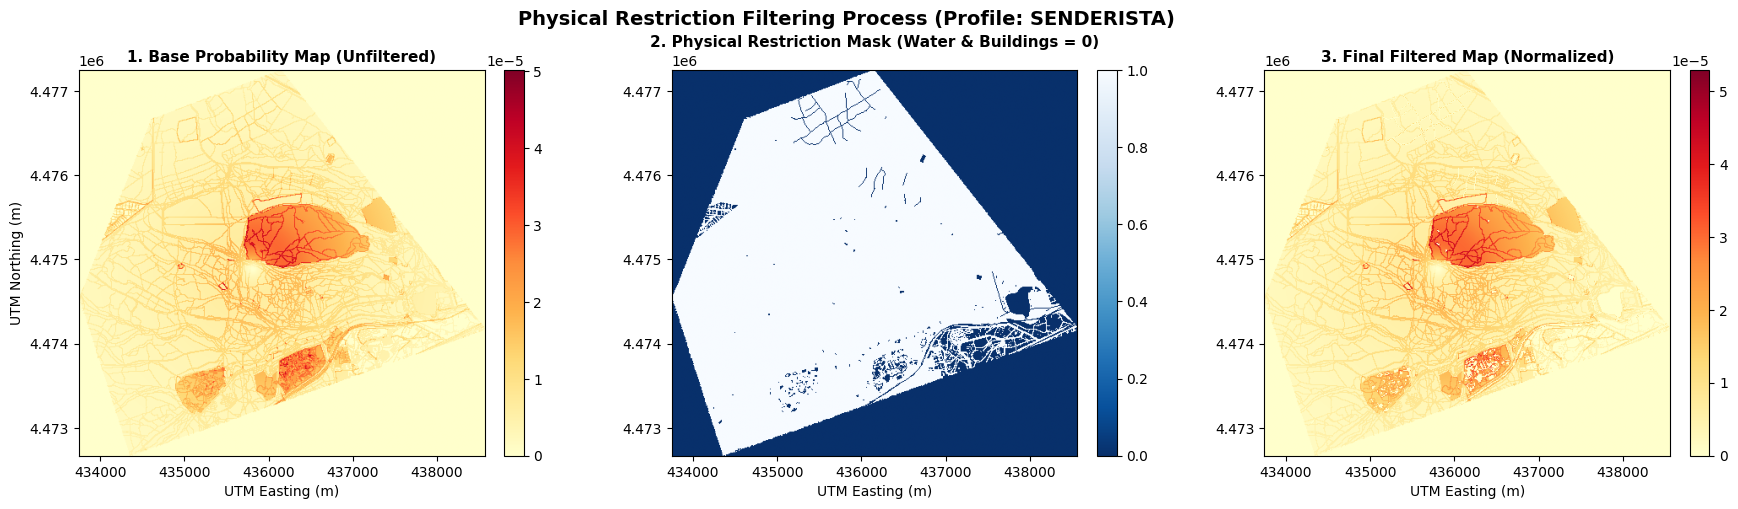

Evolución temporal b(v^k) guardada en: TFM_JC/resultados/graficas/evolucion_temporal_senderista_abc.png


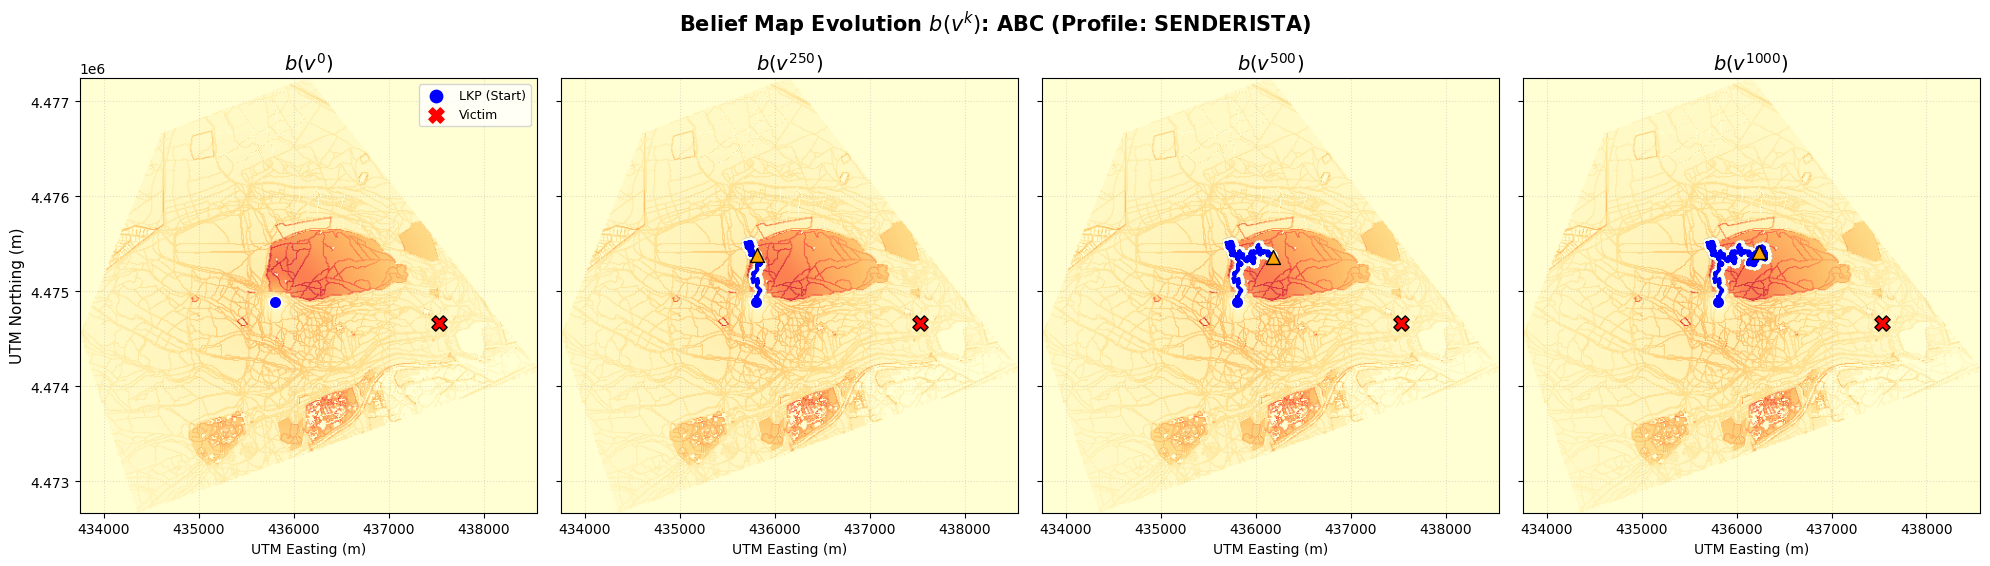

Comparativa lado a lado guardada en: TFM_JC/resultados/graficas/comparativa_evolucion_senderista_abc_vs_bha.png


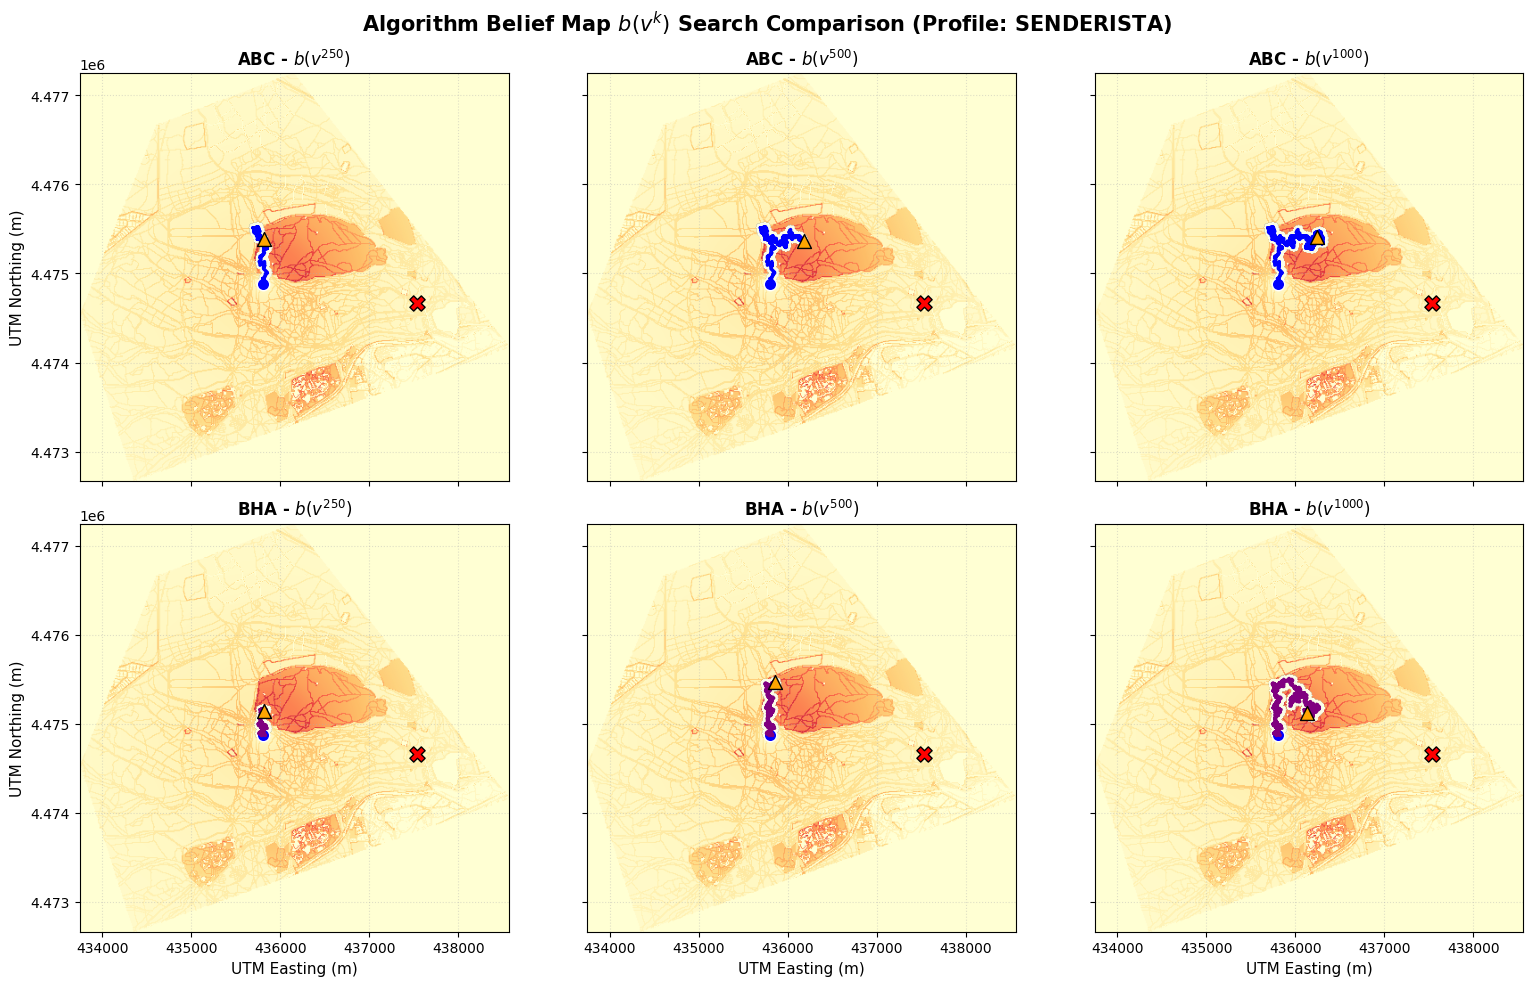

In [5]:
%matplotlib inline
import os, sys, importlib
import matplotlib.pyplot as plt
import TFM_JC.scripts.visualizacion_pro as vis_pro
importlib.reload(vis_pro)

# Renderizar figuras de evolución de trayectorias e instantes temporales b(v^k)
perfiles = ["autista", "demencia", "senderista"]

for perfil in perfiles:
    print(f"=== Mostrando Gráficas de Trayectorias y Creencias para Perfil: {perfil.upper()} ===")
    # 1. Mapa de inicio del escenario (LKP y Víctima)
    vis_pro.plot_escenario_inicial(perfil=perfil, algoritmo="ABC", semilla=1, output_path=f"TFM_JC/resultados/graficas/escenario_inicial_{perfil}.png")
    plt.show()
    
    # 2. Filtro de restricciones físicas (Antes, Máscara, Después)
    vis_pro.plot_filtro_restricciones(perfil=perfil, output_path=f"TFM_JC/resultados/graficas/filtro_restricciones_{perfil}.png")
    plt.show()
    
    # 3. Evolución temporal b(v^k) con huella del dron en azul
    vis_pro.plot_evolucion_temporal(perfil=perfil, algoritmo="ABC", semilla=1, output_path=f"TFM_JC/resultados/graficas/evolucion_temporal_{perfil}_abc.png")
    plt.show()
    
    # 4. Comparativa lado a lado entre ABC (Abejas) y BHA (Agujero Negro)
    vis_pro.plot_comparativa_algoritmos_lado_a_lado(perfil=perfil, alg1="ABC", alg2="BHA", semilla=1, output_path=f"TFM_JC/resultados/graficas/comparativa_evolucion_{perfil}_abc_vs_bha.png")
    plt.show()
